# Caderno 3 - Análise da anotação por LLM

## 1. Parâmetros de entrada

In [1]:
ARQUIVO_HUMAN_EVALS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/raw_human_eval.csv'
PASTA_LLM_EVAL = './dados/outputs/2 - llm evals/'

In [2]:
MAPA_NOME_MODELO = {
    "deepseek-chat": "deepseek",
    "gpt-5-mini-2025-08-07": "gpt-5-mini",
    "sabiazinho-4-2026-01-06": "sabiazinho-4"
}

# Guarda a ordem da lista de modelos
llm_order = [
    "deepseek_simple",
    "gpt-5-mini_simple",
    "sabiazinho-4_simple",
    "deepseek_cot",
    "gpt-5-mini_cot",
    "sabiazinho-4_cot",
]

## 2. Dataframes com as avaliações

In [3]:
import pandas as pd
import glob

# Carrega as avaliações humanas
df_human_evals = pd.read_csv(ARQUIVO_HUMAN_EVALS)

# Carrega as avaliações com LLM
arquivos_csv = glob.glob(f"{PASTA_LLM_EVAL}/*.csv")
df_llm_evals = pd.concat(
    (pd.read_csv(arquivo) for arquivo in arquivos_csv),
    ignore_index=True
)

# Para df_llm_evals ficar com o mesmo formato de df_human_evals, 
# vamos definir o avaliador como o conjunto MODELO e PROMPT
# e selecionar só as colunas que importam
df_llm_evals["USUARIO_AVALIADOR"] = (
    df_llm_evals["MODELO"].map(MAPA_NOME_MODELO).astype(str) + "_" +
    df_llm_evals["PROMPT"].astype(str)
)

df_llm_evals = df_llm_evals[["QUERY_KEY", "DOC_KEY", "AVALIACAO", "USUARIO_AVALIADOR"]]

df_all_evals = pd.concat(
    [df_human_evals, df_llm_evals],
    ignore_index=True
)

C:\Users\caris\anaconda3\Lib\site-packages\numpy\__init__.py:127: UserWarning: mkl-service package failed to import, therefore Intel(R) MKL initialization ensuring its correct out-of-the box operation under condition when Gnu OpenMP had already been loaded by Python process is not assured. Please install mkl-service package, see http://github.com/IntelPython/mkl-service
  from . import _distributor_init


## 3. Análise das anotações

### 3.1. Distribuição de labels por anotador

Primeiro define uma ordem para mostrar as avaliações

In [4]:
# 1) Humanos (ordem alfabética)
human_order = sorted(df_human_evals["USUARIO_AVALIADOR"].unique().tolist())

eval_order = human_order + llm_order

print(eval_order)

['A_1', 'A_2', 'A_3', 'A_4', 'deepseek_simple', 'gpt-5-mini_simple', 'sabiazinho-4_simple', 'deepseek_cot', 'gpt-5-mini_cot', 'sabiazinho-4_cot']



=== Label distribution (counts) per annotator ===
AVALIACAO               0     1     2  Total
USUARIO_AVALIADOR                           
A_1                   536    66   203    805
A_2                   477    80   156    713
A_3                   461   137   207    805
A_4                   451   166   108    725
deepseek_simple       420   237   155    812
gpt-5-mini_simple     215   332   265    812
sabiazinho-4_simple   290   184   338    812
deepseek_cot          397   208   207    812
gpt-5-mini_cot        216   345   251    812
sabiazinho-4_cot      209   306   297    812
Total                3672  2061  2187   7920

=== Label distribution (%) per annotator ===
AVALIACAO               0     1     2
USUARIO_AVALIADOR                    
A_1                  66.6   8.2  25.2
A_2                  66.9  11.2  21.9
A_3                  57.3  17.0  25.7
A_4                  62.2  22.9  14.9
deepseek_simple      51.7  29.2  19.1
gpt-5-mini_simple    26.5  40.9  32.6
sabiazinho-4_s

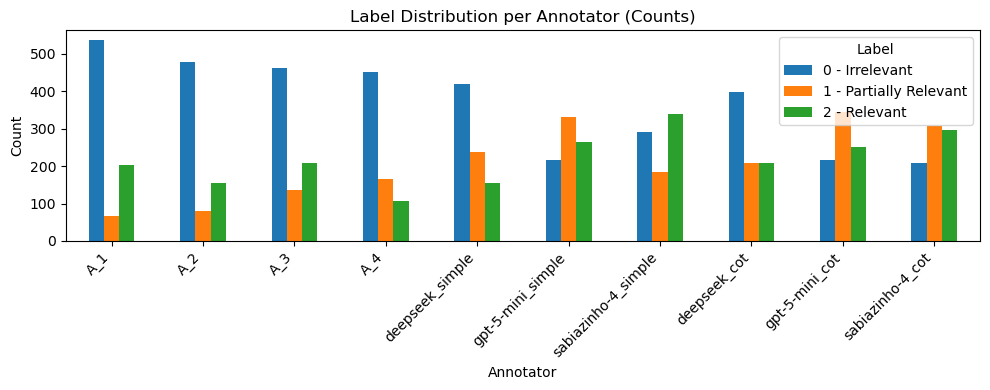

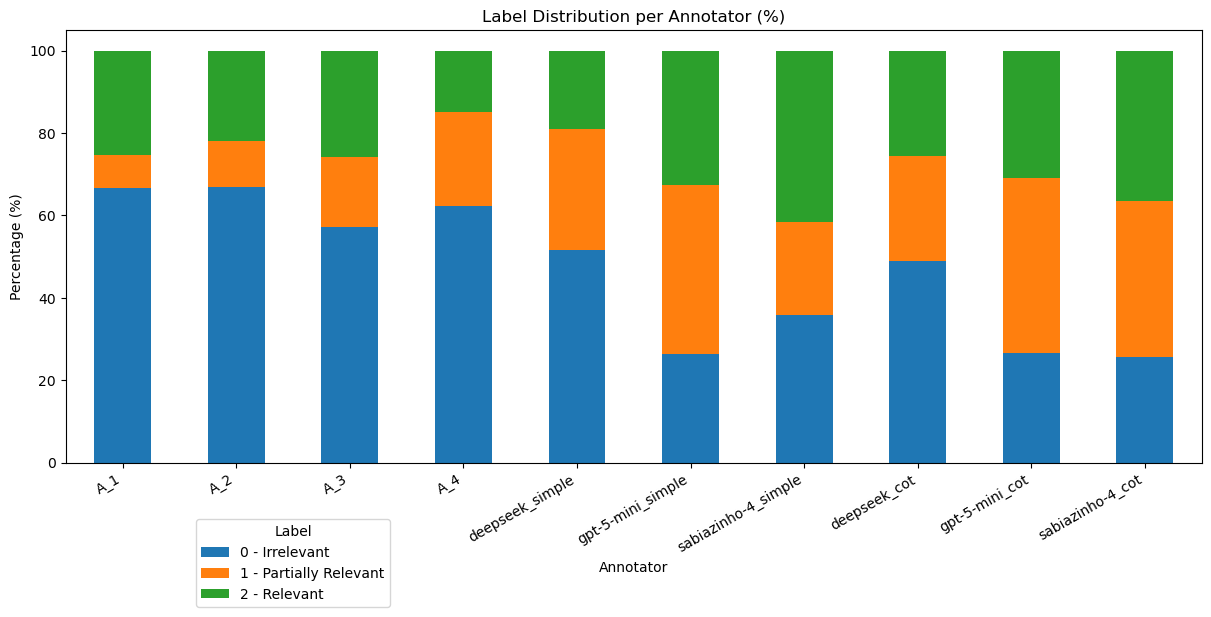

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LEVEL 1 — Individual annotator behavior
# Fixed annotator order: A_1, A_2, A_3, A_4
# ============================================================
df = df_all_evals.copy()

# ============================================================
# 1.1 Tables: label distribution per annotator
# ============================================================

# Absolute counts of labels (0/1/2)
dist_counts = (
    df.groupby(["USUARIO_AVALIADOR", "AVALIACAO"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=eval_order, fill_value=0)
      .reindex(columns=[0, 1, 2], fill_value=0)
)

# ---- Add row totals (Total per annotator)
dist_counts["Total"] = dist_counts.sum(axis=1)

# ---- Add column totals (Total per label + grand total)
column_totals = dist_counts.sum(axis=0)
dist_counts.loc["Total"] = column_totals

# Percentages (computed BEFORE adding totals row)
dist_pct = (
    df.groupby(["USUARIO_AVALIADOR", "AVALIACAO"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=eval_order, fill_value=0)
      .reindex(columns=[0, 1, 2], fill_value=0)
)

dist_pct = dist_pct.div(dist_pct.sum(axis=1), axis=0)

# ============================================================
# PRINT TABLES
# ============================================================

print("\n=== Label distribution (counts) per annotator ===")
print(dist_counts)

print("\n=== Label distribution (%) per annotator ===")
print((dist_pct * 100).round(1))

# ============================================================
# PLOTS (unchanged)
# ============================================================

# Remove the totals row for plotting
plot_counts = dist_counts.loc[eval_order, [0, 1, 2]]
plot_pct = dist_pct.loc[eval_order, [0, 1, 2]]

label_map = {
    0: "0 - Irrelevant",
    1: "1 - Partially Relevant",
    2: "2 - Relevant"
}

# ---------------------------
# 1) Grouped bar chart (counts)
# ---------------------------
ax = plot_counts.plot(kind="bar", figsize=(10, 4))
ax.set_title("Label Distribution per Annotator (Counts)")
ax.set_xlabel("Annotator")
ax.set_ylabel("Count")

# Atualiza legenda
handles, labels = ax.get_legend_handles_labels()
labels = [label_map[int(l)] for l in labels]
ax.legend(handles, labels, title="Label", ncol=1)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ---------------------------
# 2) Stacked bar chart (percentages)
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

(plot_pct * 100).plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Label Distribution per Annotator (%)")
ax.set_xlabel("Annotator")
ax.set_ylabel("Percentage (%)")

# Atualiza legenda
handles, labels = ax.get_legend_handles_labels()
labels = [label_map[int(l)] for l in labels]

ax.legend(
    handles,
    labels,
    title="Label",
    loc="lower center",
    bbox_to_anchor=(0.2, -0.35),
    ncol=1
)

# Inclina rótulos do eixo x
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

#plt.savefig("label_distribution_percentage_human_and_llm.png", dpi=300, bbox_inches="tight")
plt.show()

Cálculo do viés LLM - HUMANO

In [6]:
# Média humana por par QUERY_KEY-DOC_KEY (isso é o mesmo que gerar o qrels novamente, podia ter só aberto de lá)
human_mean = (
    df_all_evals[
        df_all_evals["USUARIO_AVALIADOR"].isin(human_order)
    ]
    .groupby(["QUERY_KEY", "DOC_KEY"])["AVALIACAO"]
    .mean()
    .reset_index()
    .rename(columns={"AVALIACAO": "media_humana"})
)

In [7]:
# Cria um df com todas as avaliações, mas adicionando a coluna indicando a média das avaliações humanas
df_with_hmean = df_all_evals.merge(
    human_mean,
    on=["QUERY_KEY", "DOC_KEY"],
    how="left"
)

# Adiciona uma coluna indicando o viés da avaliação do avaliador com a média humana
df_with_hmean["diferenca"] = df_with_hmean["AVALIACAO"] - df_with_hmean["media_humana"]
# Adiciona também o módulo da diferença
df_with_hmean["diferenca_modulo"] = df_with_hmean["diferenca"].abs()

In [8]:
# Exibe o resultado da diferença média de cada avaliador com a média humana
resultado = (
    df_with_hmean
    .groupby('USUARIO_AVALIADOR')
    .agg(
        erro_medio=('diferenca', 'mean'),
        desvio_erro_medio=('diferenca', 'std'),
        erro_absoluto_medio=('diferenca_modulo', 'mean'),
        desvio_erro_absoluto_medio=('diferenca_modulo', 'std'))
    .reindex(eval_order)
    .reset_index()
)

# Todos os avaliadores
pd.options.display.float_format = "{:.2f}".format
print("\n=== Viés médio (avaliador - média humana) ===")
print(resultado)
# Apenas os LLMs
print("\n=== Viés médio (LLM - média humana) ===")
print(resultado[resultado["USUARIO_AVALIADOR"].isin(llm_order)])


=== Viés médio (avaliador - média humana) ===
     USUARIO_AVALIADOR  erro_medio  desvio_erro_medio  erro_absoluto_medio  \
0                  A_1        0.00               0.43                 0.25   
1                  A_2       -0.04               0.39                 0.22   
2                  A_3        0.10               0.49                 0.29   
3                  A_4       -0.08               0.39                 0.23   
4      deepseek_simple        0.08               0.70                 0.46   
5    gpt-5-mini_simple        0.47               0.70                 0.60   
6  sabiazinho-4_simple        0.47               0.80                 0.64   
7         deepseek_cot        0.18               0.73                 0.48   
8       gpt-5-mini_cot        0.45               0.68                 0.58   
9     sabiazinho-4_cot        0.52               0.73                 0.66   

   desvio_erro_absoluto_medio  
0                        0.35  
1                        0.32 

## 3.2. Verifica, para cada modelo/prompt, se a avaliação está dentro das avaliações humanas

Agrupa, para cada par query documento, os valores mínimos e máximos das anotações humanas

In [9]:
human_interval = (
    df_human_evals
    .groupby(["QUERY_KEY", "DOC_KEY"])["AVALIACAO"]
    .agg(["min", "max"])
    .reset_index()
)

Insere a coluna min/max (merge) calculada anteriormente com o df das avaliações humanas.

Da forma como as avaliações por LLM foram feitas, só tem uma avaliação por usuário_avaliador.

In [10]:
df_llm_with_human_interval = df_llm_evals.merge(
    human_interval,
    on=["QUERY_KEY", "DOC_KEY"],
    how="left"
)

Cria uma coluna indicando se a avaliação do LLM está dentro do intervalo humano ou não.

In [11]:
df_llm_with_human_interval["DENTRO_INTERVALO"] = (
    (df_llm_with_human_interval["AVALIACAO"] >= df_llm_with_human_interval["min"]) &
    (df_llm_with_human_interval["AVALIACAO"] <= df_llm_with_human_interval["max"])
)

Vamos criar uma coluna indicando também o tipo de divergência humana (max - min):

In [12]:
df_llm_with_human_interval["DIV_AVALIACAO_HUMANA"] = df_llm_with_human_interval['max']-df_llm_with_human_interval['min']

Para cada nível de divergência humana (consenso, divergência fraca (dif = 1) e divergência total (dif = 2)), verifica o percentual por modelo/prompt que está dentro das avaliações humanas.

In [13]:
resultado_div = (
    df_llm_with_human_interval
    .groupby(["USUARIO_AVALIADOR", "DIV_AVALIACAO_HUMANA"])["DENTRO_INTERVALO"]
    .agg(["sum", "count"])
    .reset_index()
)

resultado_div["percentual_dentro"] = (
    resultado_div["sum"] / resultado_div["count"] * 100
).round(2)

# Definir ordem categórica personalizada
resultado_div["USUARIO_AVALIADOR"] = pd.Categorical(
    resultado_div["USUARIO_AVALIADOR"],
    categories=eval_order,
    ordered=True
)

# Ordenar primeiro por DIV, depois pelo avaliador
resultado_div = resultado_div.sort_values(
    by=["DIV_AVALIACAO_HUMANA", "USUARIO_AVALIADOR"]
).reset_index(drop=True)

print(resultado_div)

      USUARIO_AVALIADOR  DIV_AVALIACAO_HUMANA  sum  count  percentual_dentro
0       deepseek_simple                     0  329    437              75.29
1     gpt-5-mini_simple                     0  247    437              56.52
2   sabiazinho-4_simple                     0  282    437              64.53
3          deepseek_cot                     0  332    437              75.97
4        gpt-5-mini_cot                     0  252    437              57.67
5      sabiazinho-4_cot                     0  233    437              53.32
6       deepseek_simple                     1  192    225              85.33
7     gpt-5-mini_simple                     1  180    225              80.00
8   sabiazinho-4_simple                     1  164    225              72.89
9          deepseek_cot                     1  186    225              82.67
10       gpt-5-mini_cot                     1  191    225              84.89
11     sabiazinho-4_cot                     1  173    225              76.89

Calcula tbm o percentual global por modelo/prompt:

In [14]:
resultado_div = (
    df_llm_with_human_interval
    .groupby(["USUARIO_AVALIADOR"])["DENTRO_INTERVALO"]
    .agg(["sum", "count"])
    .reset_index()
)

resultado_div["percentual_dentro"] = (
    resultado_div["sum"] / resultado_div["count"] * 100
)

print(resultado_div)

     USUARIO_AVALIADOR  sum  count  percentual_dentro
0         deepseek_cot  668    812              82.27
1      deepseek_simple  671    812              82.64
2       gpt-5-mini_cot  593    812              73.03
3    gpt-5-mini_simple  577    812              71.06
4     sabiazinho-4_cot  556    812              68.47
5  sabiazinho-4_simple  596    812              73.40


## 3.3. Kappa de Cohen

In [15]:
from sklearn.metrics import cohen_kappa_score
from itertools import combinations
import pandas as pd
import numpy as np

annotators = eval_order

# Wide format: rows=(QUERY_KEY, DOC_KEY), cols=annotators
wide = df_all_evals.pivot_table(
    index=["QUERY_KEY", "DOC_KEY"],
    columns="USUARIO_AVALIADOR",
    values="AVALIACAO",
    aggfunc="first"
).reindex(columns=annotators)

# Criar matriz vazia
kappa_matrix = pd.DataFrame(
    np.nan,
    index=annotators,
    columns=annotators
)

# Preencher diagonal com 1 (concordância perfeita consigo mesmo)
for a in annotators:
    kappa_matrix.loc[a, a] = 1.0

# Calcular kappas par-a-par
for a1, a2 in combinations(annotators, 2):
    
    sub = wide[[a1, a2]].dropna()
    
    kappa = cohen_kappa_score(
        sub[a1],
        sub[a2],
        weights="quadratic"
    )
    
    kappa_matrix.loc[a1, a2] = kappa
    kappa_matrix.loc[a2, a1] = kappa  # matriz simétrica

print("\n=== Pairwise Weighted Cohen's Kappa (quadratic) ===")
print(kappa_matrix.round(4))


=== Pairwise Weighted Cohen's Kappa (quadratic) ===
                     A_1  A_2  A_3  A_4  deepseek_simple  gpt-5-mini_simple  \
A_1                 1.00 0.73 0.55 0.67             0.51               0.46   
A_2                 0.73 1.00 0.61 0.70             0.46               0.36   
A_3                 0.55 0.61 1.00 0.58             0.42               0.39   
A_4                 0.67 0.70 0.58 1.00             0.44               0.37   
deepseek_simple     0.51 0.46 0.42 0.44             1.00               0.63   
gpt-5-mini_simple   0.46 0.36 0.39 0.37             0.63               1.00   
sabiazinho-4_simple 0.42 0.33 0.39 0.32             0.65               0.78   
deepseek_cot        0.53 0.44 0.43 0.44             0.82               0.69   
gpt-5-mini_cot      0.47 0.38 0.41 0.38             0.64               0.91   
sabiazinho-4_cot    0.41 0.34 0.37 0.33             0.63               0.79   

                     sabiazinho-4_simple  deepseek_cot  gpt-5-mini_cot  \
A_1

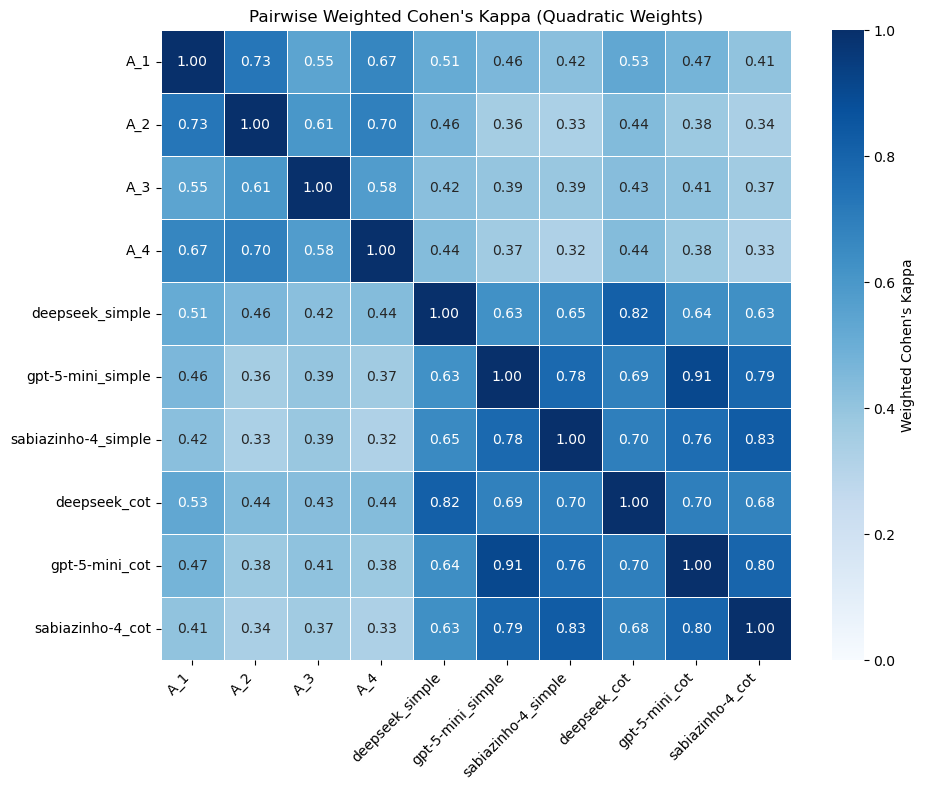

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Garante que os valores são float
kappa_plot = kappa_matrix.astype(float)

# Cria figura maior (nomes longos precisam de espaço)
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    kappa_plot,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Weighted Cohen's Kappa"}
)

plt.title("Pairwise Weighted Cohen's Kappa (Quadratic Weights)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
#plt.savefig("cohen_kappa_human_and_llm.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.4. Alpha de Krippendorff

Entre os anotadores humanos:

In [17]:
import krippendorff
import numpy as np

human_annotators = ["A_1", "A_2", "A_3", "A_4"]

# Matriz: linhas = anotadores, colunas = itens
data_human = wide[human_annotators].to_numpy().T

alpha_humans = krippendorff.alpha(
    reliability_data=data_human,
    level_of_measurement="ordinal"
)

print("Krippendorff alpha (Humans only):")
print(round(alpha_humans, 4))

Krippendorff alpha (Humans only):
0.6188
